<a href="https://colab.research.google.com/github/leduynhut09022021-creator/baitaptuan1/blob/main/tuan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.datasets import mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


so: 0


(10000,)

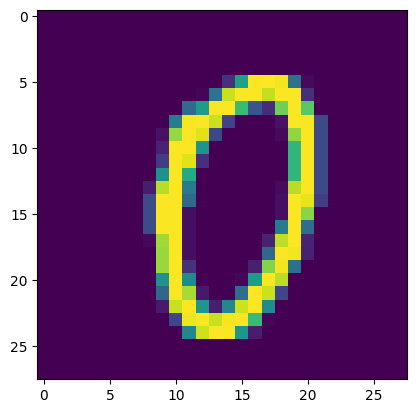

In [5]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1000])
print('so:',y_train[1000])


In [7]:
x_train.shape



(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
y_train.shape

(60000,)

In [10]:
y_test.shape

(10000,)

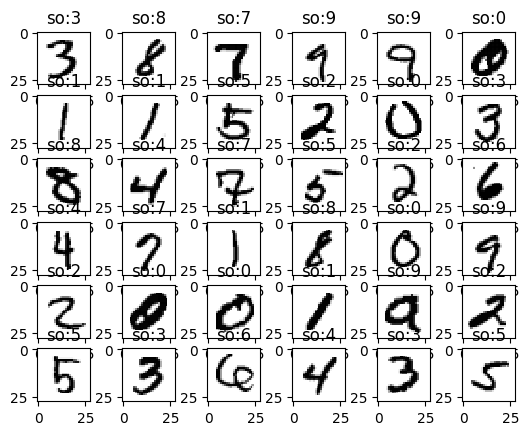

In [12]:
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.imshow(x_train[10000+i],cmap='binary',interpolation='none')
  plt.title('so:{}'.format(y_train[10000+i]))

In [ ]:
x_train=x_train.reshape(60000,28*28)
x_test=x_test.reshape(10000,28*28)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255


In [ ]:
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)#10 nhom
y_test=to_categorical(y_test,10)

In [15]:
from keras.models import Sequential
from keras.layers import Dense# Dense=fullconected
model= Sequential()
model.add(Dense(512,activation='relu',input_shape=(28*28,)))
model.add(Dense(256,activation='softmax'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
x_train=x_train.reshape(60000,28*28)
x_test=x_test.reshape(10000,28*28)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.1116 - loss: 2.3016
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.1124 - loss: 2.3014
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.1124 - loss: 2.3014
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.1124 - loss: 2.3014
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.1124 - loss: 2.3014


In [70]:
x_train=x_train.reshape(50000,32*32*3)
x_test=x_test.reshape(10000,32*32*3)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5)

Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_13' is incompatible with the layer: expected axis -1 of input shape to have value 784, but received input with shape (None, 3072)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 3072), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [39]:
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("/content/so9.jpg")
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_gray=cv2.resize(img_gray,(28,28))
img_inverted=255-img_gray


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


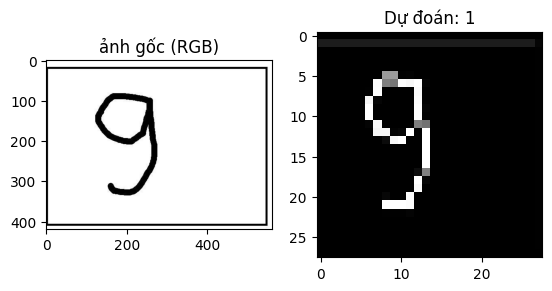

In [40]:
import numpy as np
import matplotlib.pyplot as plt

img_ready=img_inverted.reshape((1,28*28))
img_ready=img_ready.astype('float32')
img_ready/=255

preds = model.predict(img_ready)
digit = np.argmax(preds)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("ảnh gốc (RGB)")
plt.subplot(1,2,2)
plt.imshow(img_inverted, cmap='gray')
plt.title(f"Dự đoán: {digit}")
plt.show()


In [41]:
from keras.datasets import fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
x_train.shape

(60000, 28, 28)

In [46]:
x_test.shape

(10000, 28, 28)

In [47]:
y_train.shape


(60000,)

In [48]:
y_test.shape

(10000,)

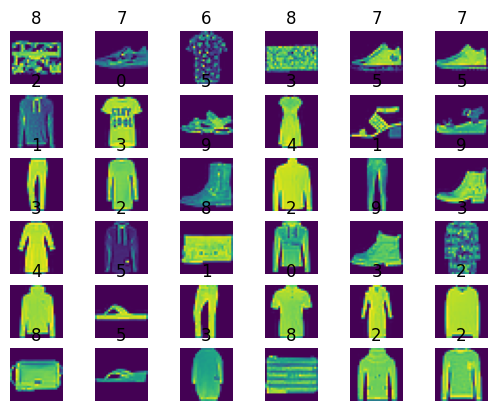

In [45]:
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.imshow(x_train[10000+i])
  plt.title(y_train[10000+i])
  plt.axis('off')

In [49]:
x_train=x_train.reshape(60000,28*28)
x_test=x_test.reshape(10000,28*28)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255

In [50]:
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)#10 nhom
y_test=to_categorical(y_test,10)

In [55]:
from keras.models import Sequential
from keras.layers import Dense# Dense=fullconected
model= Sequential()
model.add(Dense(512,activation='relu',input_shape=(28*28,)))
model.add(Dense(256,activation='softmax'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("/content/unnamed.jpg")
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_gray=cv2.resize(img_gray,(28,28))
img_inverted=255-img_gray

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


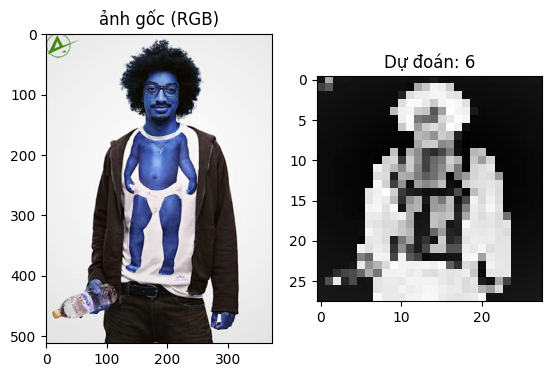

In [60]:
import numpy as np
import matplotlib.pyplot as plt

img_ready=img_inverted.reshape((1,28*28))
img_ready=img_ready.astype('float32')
img_ready/=255

preds = model.predict(img_ready)
digit = np.argmax(preds)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("ảnh gốc (RGB)")
plt.subplot(1,2,2)
plt.imshow(img_inverted, cmap='gray')
plt.title(f"Dự đoán: {digit}")
plt.show()


In [61]:
from keras.datasets import cifar10
(x_train,y_train),(x_test,y_test)= cifar10.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


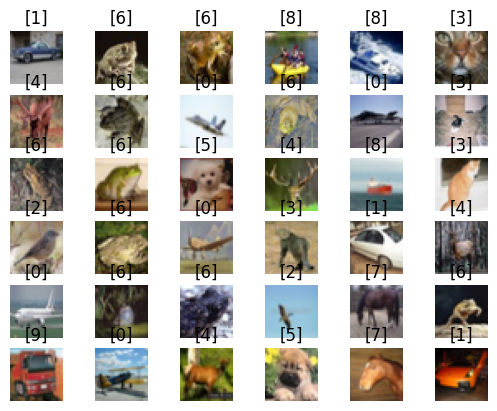

In [62]:
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.imshow(x_train[10000+i])
  plt.title(y_train[10000+i])
  plt.axis('off')

In [64]:
x_train=x_train.reshape(50000,32*32*3)
x_test=x_test.reshape(10000,32*32*3)
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255

In [65]:
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)#10 nhom
y_test=to_categorical(y_test,10)

In [71]:
from keras.models import Sequential
from keras.layers import Dense# Dense=fullconected
model= Sequential()
model.add(Dense(512,activation='relu',input_shape=(32*32*3,)))
model.add(Dense(256,activation='softmax'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
from keras.datasets import cifar10
from keras.utils import to_categorical

# Load CIFAR-10 dataset to ensure we're using the correct data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Preprocess x_train and x_test
# Reshape for dense layer: (num_samples, 32*32*3)
x_train = x_train.reshape(x_train.shape[0], 32*32*3)
x_test = x_test.reshape(x_test.shape[0], 32*32*3)
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Preprocess y_train and y_test (one-hot encode)
num_classes = 10 # CIFAR-10 has 10 classes
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.1917 - loss: 2.1686
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - accuracy: 0.2228 - loss: 2.0457
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.2421 - loss: 1.9918
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.2630 - loss: 1.9433
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.2927 - loss: 1.8830


In [89]:
import cv2
img = cv2.imread("/content/Green-frog.jpg")
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (32,32)) # Resize the color image
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img_gray = cv2.resize(img_gray, (32,32))
img_inverted = 255 - img_gray

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


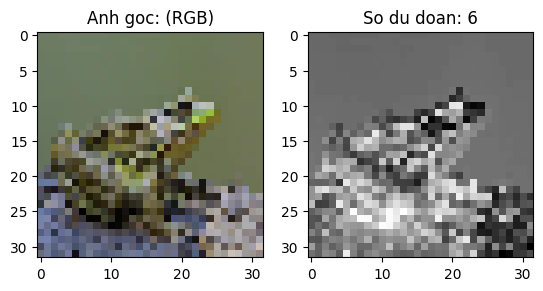

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
img_for_model = cv2.resize(img, (32, 32))
img_ready = img_for_model.reshape((1, 32*32*3))
img_ready = img_ready.astype("float32")/255

preds = model.predict(img_ready)
digit = np.argmax(preds)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Anh goc: (RGB)")

plt.subplot(1,2,2)
plt.imshow(img_inverted,cmap = "gray")
plt.title(f"So du doan: {digit}")
plt.show()

In [81]:
from keras.utils import load_img,img_to_array
import numpy as np # Import numpy
img=load_img("/content/Green-frog.jpg",target_size=(32,32))
img=img_to_array(img)
img=img.reshape((1,32*32*3)) # Flatten the image
img=img.astype('float32')
img=img/255.0
np.argmax(model.predict(img),axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([6])